# Theoretical peptides and their spectra

This notebook generated a few theoretical plots of the search space for the following peptides;

- Peptide
- Peptide with a PTM
- Peptide with a sequence based modifier, SBM

In [1]:
import numpy as np 
import matplotlib.pyplot as plt

plt.rcParams["font.family"] = "Arial" 

In [2]:
sequence = "PEPTIDE"

In [3]:
def theo_peaks(sequence):
    aas = {
        "A": 71.03711, "R": 156.10111, "N": 115.02694,
        "D": 115.02694, "C": 103.00919, "E": 129.04259,
        "Q": 128.05858, "G": 57.02146, "H": 137.05891,
        "I": 113.08406, "L": 113.08406, "K": 128.09496,
        "M": 131.04049, "F": 147.06841, "P": 97.05276,
        "S": 87.03203, "T": 101.04768, "W": 186.07931,
        "Y": 163.06333, "V": 99.06841
    }

    bs = []
    ys = []

    for split_position in range(1, len(sequence)):
        part1 = sequence[:split_position]
        part2 = sequence[split_position:]

        mass1 = sum(aas[aa] for aa in part1)
        mass2 = sum(aas[aa] for aa in part2)

        part1 = "b" + str(split_position) 
        part2 = "y" + str(len(sequence) - split_position)

        bs.append((part1, mass1))
        ys.append((part2, mass2))

    return bs, ys

In [4]:
b, y = theo_peaks(sequence)
b

[('b1', 97.05276),
 ('b2', 226.09535),
 ('b3', 323.14811),
 ('b4', 424.19579),
 ('b5', 537.27985),
 ('b6', 652.30679)]

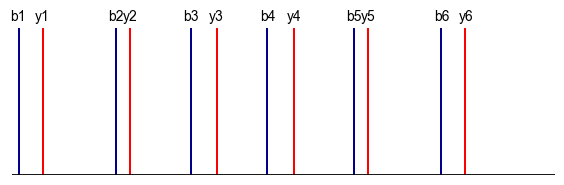

In [5]:

mass_values1 = [mass[1] for mass in b]
mass_values2 = [mass[1] for mass in y]

plt.figure(figsize=(7, 2))

plt.hist(mass_values1, bins=200, color='darkblue', label='b', edgecolor='none')
plt.hist(mass_values2, bins=200, color='red', label='y', edgecolor='none')

plt.xlabel('Mass')
plt.ylabel('')
plt.title('')
plt.xticks(rotation=90)
plt.xticks(mass_values1 + mass_values2)  
plt.yticks([])
plt.xlim([90,800])

label_offset = 0.15  
for i in range(len(b)):
    plt.text(mass_values1[i], 0.9 + label_offset, b[i][0], ha='center', rotation= 0)

for i in range(len(y)):
    plt.text(mass_values2[i], 0.9 + label_offset, y[i][0], ha='center', rotation= 0)

plt.axhline(0, color='black', linewidth=2)
plt.box(False)
plt.axis('off')
plt.show()

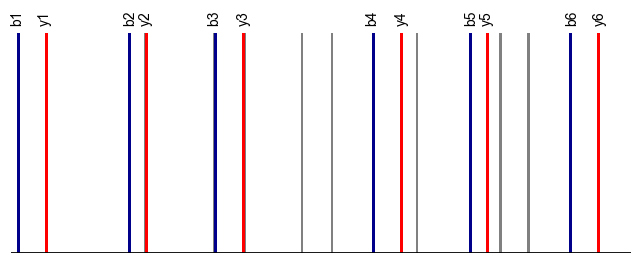

In [6]:
mass_values_ptm_b = [mass[1] for mass in b]
mass_values_ptm_y = [mass[1] for mass in y]

for i in range(len(mass_values_ptm_b) + 1): 
    if i > 3: 
        mass_values_ptm_b[i - 1] += 80
        mass_values_ptm_y[len(mass_values_ptm_b) - i] += 80

plt.figure(figsize=(8, 3))

plt.hist(mass_values1, bins=200, color='gray', label='b', edgecolor='none')
plt.hist(mass_values2, bins=200, color='gray', label='y', edgecolor='none')

plt.hist(mass_values_ptm_b, bins=200, color='darkblue', label='b', edgecolor='none')
plt.hist(mass_values_ptm_y, bins=200, color='red', label='y', edgecolor='none')

plt.xlabel('Mass')
plt.ylabel('')
plt.title('')
plt.xticks(rotation=90)
plt.xticks() 
plt.yticks([])
plt.xlim([90,800])

label_offset = 0.15 
for i in range(len(b)):
    plt.text(mass_values_ptm_b[i], 0.9 + label_offset, b[i][0], ha='center', rotation= 90)

for i in range(len(y)):
    plt.text(mass_values_ptm_y[i], 0.9 + label_offset, y[i][0], ha='center', rotation= 90)

plt.axhline(0, color='black', linewidth=2)
plt.box(False)
plt.axis('off')
plt.show()


In [7]:
def calc_peaks(mass, existing_fragment = None, existing_mass = None ):  
    """Calculates all possible peaks after considering additional fragmentation. """ 
    
    G = 57.02146
    GG = G + G 
    GGT = G + G + 101.04768
    GGTQ = GGT + 128.05858
    GGTQQ = GGTQ + 128.05858
    GGTQQQ = GGTQQ + 128.05858
    GGTQQQF = GGTQQQ + 147.06841
    GGTQQQFV = GGTQQQF + 99.06841
    GGTQQQFVD = GGTQQQFV + 115.02694
    
    #if existing_fragment != None:
    #    mass = mass - existing_fragment 
        
    if existing_mass != None:
        mass = mass - existing_mass 
    
    #fragment_masses = [G, GGT, GGTQ, GGTQQ, GGTQQQ, GGTQQQF, GGTQQQFV]
    #names = ["G", "GGT", "GGTQ", "GGTQQ", "GGTQQQ", "GGTQQQF", "GGTQQQFV"]

    fragment_masses = [G, GGT, GGTQ, GGTQQ, GGTQQQ, GGTQQQF, GGTQQQFV, GGTQQQFVD]
    names = ["G", "GGT", "GGTQ", "GGTQQ", "GGTQQQ", "GGTQQQF", "GGTQQQFV", "GGTQQQFVD"]

    peptide_and_modification = []
    
    for i in range(len(fragment_masses)): 
        peptide_and_modification.append(mass + fragment_masses[i])  
        #print( "-" + names[i] + ": " + str(mass + fragment_masses[i]))
        
    return peptide_and_modification  

In [8]:
test_mass = calc_peaks(mass_values_ptm_b[1])
test_mass

s_mass = calc_peaks(0)
s_mass

[57.02146,
 215.0906,
 343.14918,
 471.20776,
 599.26634,
 746.33475,
 845.40316,
 960.4300999999999]

In [9]:
test_list = test_mass + test_mass
print(test_list)

[283.11681, 441.18595, 569.2445299999999, 697.3031100000001, 825.36169, 972.4301, 1071.49851, 1186.5254499999999, 283.11681, 441.18595, 569.2445299999999, 697.3031100000001, 825.36169, 972.4301, 1071.49851, 1186.5254499999999]


In [12]:
G = 57.02146
GG = G + G 
GGT = G + G + 101.04768
GGTQ = GGT + 128.05858
GGTQQ = GGTQ + 128.05858
GGTQQQ = GGTQQ + 128.05858
GGTQQQF = GGTQQQ + 147.06841
GGTQQQFV = GGTQQQF + 99.06841
GGTQQQFVD = GGTQQQFV + 115.02694

fragment_masses = [G, GGT, GGTQ, GGTQQ, GGTQQQ, GGTQQQF, GGTQQQFV, GGTQQQFVD]
names = ["G", "GGT", "GGTQ", "GGTQQ", "GGTQQQ", "GGTQQQF", "GGTQQQFV", "GGTQQQFVD"]

mass_values_ptm_b = [mass[1] for mass in b] 
mass_values_ptm_y = [mass[1] for mass in y]

sumo_masses_b = []
sumo_masses_y = []

for i in range(len(mass_values_ptm_b)): 
    #print(i)
    #print(mass_values_ptm_b[i])
    if i >= 3: 
        print(i)
        print(mass_values_ptm_b[i])
        sumo_masses_b = sumo_masses_b + calc_peaks(mass_values_ptm_b[i])
        sumo_masses_y = sumo_masses_y + calc_peaks(mass_values_ptm_y[len(mass_values_ptm_b) - i])

3
424.19579
4
537.27985
5
652.30679


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


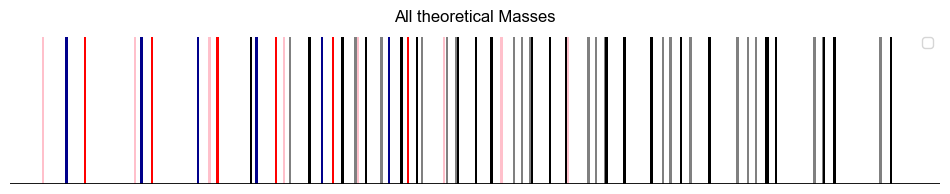

In [18]:
plt.figure(figsize=(12, 2))

plt.bar(sumo_masses_b, height=1, width=4, color='grey') # , label='b'
plt.bar(sumo_masses_y, height=1, width=4, color='black', edgecolor='none') # label='y',

plt.bar(mass_values1, height=1, width=4, color='darkblue', edgecolor='none')
plt.bar(mass_values2, height=1, width=4, color='red', edgecolor='none')

# Highlight fragment masses in pink
plt.bar(fragment_masses, height=1, width=4, color='pink', edgecolor='none')

# Labeling
#for i, mass in enumerate(fragment_masses):
#    plt.text(mass, 0.9, names[i], ha='center', rotation=90)

plt.xlabel('Mass')
plt.ylabel('')
plt.title('All theoretical Masses')
plt.xticks(rotation=90)
plt.yticks([])
plt.xlim([0, 1600])
plt.axhline(0, color='black', linewidth=2)
plt.box(False)
plt.axis('off')
plt.legend()
plt.show()

[481.21725, 639.28639, 767.34497, 895.40355, 1023.46213, 1170.53054, 1269.59895, 1384.6258899999998, 594.3013100000001, 752.37045, 880.42903, 1008.48761, 1136.54619, 1283.6145999999999, 1382.68301, 1497.70995, 709.32825, 867.39739, 995.45597, 1123.5145499999999, 1251.57313, 1398.64154, 1497.70995, 1612.73689]


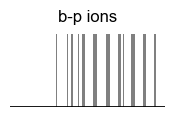

[414.17505, 572.24419, 700.30277, 828.36135, 956.41993, 1103.4883399999999, 1202.55675, 1317.58369, 515.2227300000001, 673.29187, 801.35045, 929.40903, 1057.4676100000001, 1204.53602, 1303.6044299999999, 1418.63137, 612.27549, 770.3446299999999, 898.40321, 1026.4617899999998, 1154.52037, 1301.58878, 1400.65719, 1515.6841299999999]


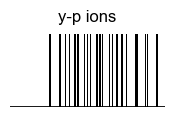

[97.05276, 226.09535, 323.14811, 424.19579, 537.27985, 652.30679]


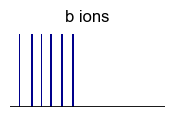

[684.29662, 555.25403, 458.20127, 357.15359, 244.06953, 129.04259]


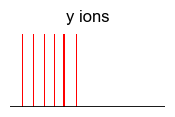

[57.02146, 215.0906, 343.14918, 471.20776, 599.26634, 746.33475, 845.40316, 960.4300999999999]


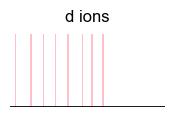

In [20]:
colors = [('grey', sumo_masses_b, 'b-p ions'), ('black', sumo_masses_y, 'y-p ions'), ('darkblue', mass_values1, 'b ions'), ('red', mass_values2, 'y ions'), ('pink', fragment_masses, 'd ions')]

for color, masses, label in colors:
    print(masses)
    plt.figure(figsize=(2, 1))
    plt.bar(masses, height=0.5, width=15, color=color, edgecolor='none', label=label)
    plt.xlabel('Mass')
    plt.ylabel('')
    plt.title(f'{label}')
    plt.xticks(rotation=90)
    plt.yticks([])
    plt.xlim([0, 1600])
    plt.axhline(0, color='black', linewidth=2)
    plt.box(False)
    plt.axis('off')
    plt.show()
